# Explicar no es entender: IA explicativa y sus límites causales
## Estudio de caso — Selección de sitios de anidación de la tórtola senegalesa (*Spilopelia senegalensis*) en Karaj, Irán

**Maestría en Ciencia de Datos — Universidad Santo Tomás**
**María Angélica Ardila Flórez
**Actividad 1 — Taller práctico individual**

---

Este cuaderno desarrolla las seis fases de la guía de actividades:

| Fase | Contenido |
|---|---|
| 1 | Definición del problema y de los datos |
| 2 | Entrenamiento del modelo de caja negra (Random Forest) |
| 3 | Explicación global y local (SHAP, LIME, PDP/ICE, ALE) |
| 4 | SHAP intervencional y límites de la explicación |
| 5 | Formulación de la pregunta causal |
| 6 | Conclusiones y reproducibilidad |

**Datos:** Banisaffar, M., y Alizadeh Shabani, A. (2024). *Factors influencing nest site selection of the Laughing Dove (Spilopelia senegalensis) in an urban area in Karaj, Iran* [Conjunto de datos]. Dryad.

**Reproducibilidad:** todas las semillas están fijadas en `RS = 42`.

In [10]:
# Instalación de dependencias
!pip install -q shap lime dice-ml PyALE openpyxl

In [11]:
import warnings, os
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             f1_score, roc_auc_score, classification_report, RocCurveDisplay)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from scipy.stats import chi2_contingency, kruskal
import shap
from lime.lime_tabular import LimeTabularExplainer

RS = 42
np.random.seed(RS)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})
print("scikit-learn", __import__("sklearn").__version__, "| shap", shap.__version__)

scikit-learn 1.6.1 | shap 0.52.0


---
# Fase 1 — Definición del problema y de los datos

**¿Qué predice el modelo?** La probabilidad de que un sitio urbano concreto presente un nido de tórtola senegalesa (`P_A` = P) frente a que no lo presente (`P_A` = A), a partir de diez descriptores físicos del sitio. Es un problema de **clasificación binaria supervisada** de naturaleza **asociativa**: el modelo aprende qué configuraciones de sitio *co-ocurren* con la presencia de nido en la muestra observada.

**¿Para qué podría ser útil?** Para priorizar la inspección de estructuras urbanas antes de obras de mantenimiento de fachadas, para orientar el diseño de estructuras urbanas favorables o disuasorias, y para muestreos dirigidos en estudios de ecología urbana. En todos estos usos el valor está en *dónde mirar primero*, no en *qué intervenir*.

**Condiciones del sitio frente a acompañantes o proxies.** Distinguimos tres grupos:

- **Condiciones estructurales del micrositio** (candidatas a ser causalmente relevantes para el ave): `HEIGHT`, `CEILING`, `H_CEILING`, `CONCEAL`, `B_STRUCT`, `B_ASPECT`. Describen la cavidad o repisa donde el nido se construye: cuánto protege, cuánto oculta, cómo se orienta.
- **Contexto del paisaje**: `TREE_DIST`, `GREEN_DIST`, `BUILD_DIST`. Describen el entorno, no el sitio. Su efecto sobre el ave es plausiblemente indirecto (disponibilidad de alimento, corredores de vuelo).
- **Variable claramente acompañante**: `NEST_DIST`, la distancia al nido más cercano. **No es una condición del sitio sino una consecuencia del propio patrón de anidación**: si hay nidos cerca, es más probable que este sitio también tenga uno, porque los nidos se agregan espacialmente. Usarla como predictor genera fuga de información espacial (*spatial leakage*) y la convierte en el proxy más peligroso del conjunto.

**¿Por qué explicar y no solo medir?** Con n = 96 y desbalance 32/64, una métrica agregada como el ROC AUC no dice *sobre qué* está apoyándose el modelo. La explicación permite (i) auditar si el desempeño proviene de señal ecológica o de un atajo estadístico como `NEST_DIST`, (ii) comunicar el modelo a un público de ecólogos que necesita interpretar, no solo predecir, y (iii) delimitar explícitamente hasta dónde llega la evidencia, que es el objetivo central de esta actividad.

In [12]:
import os
ARCHIVO = "Sitios_anidacion_tortola.xlsx"
URL = "https://raw.githubusercontent.com/mardilaf/IAX/main/Sitios_anidacion_tortola.xlsx"

if not os.path.exists(ARCHIVO):
    import urllib.request
    urllib.request.urlretrieve(URL, ARCHIVO)

print("Archivo disponible:", os.path.exists(ARCHIVO))

Archivo disponible: True


In [13]:
df = pd.read_excel("Sitios_anidacion_tortola.xlsx", sheet_name="Datos")
print("Dimensiones:", df.shape, "| valores faltantes:", int(df.isna().sum().sum()))
print(df["P_A"].value_counts().to_string())
df.head()

Dimensiones: (96, 11) | valores faltantes: 0
P_A
A    64
P    32


,P_A,HEIGHT,CEILING,H_CEILING,TREE_DIST,BUILD_DIST,GREEN_DIST,NEST_DIST,CONCEAL,B_ASPECT,B_STRUCT
0,P,318,127,94,8,18,158.2,141.8,A,D,A
1,P,284,96,23,6,25,111.5,44.2,B,A,A
2,P,299,24,117,11,25,90.4,44.2,A,A,A
3,P,340,95,18,8,25,144.0,217.1,A,A,A
4,P,367,23,26,8,17,307.6,103.2,B,A,A


In [14]:
NUM = ["HEIGHT","CEILING","H_CEILING","TREE_DIST","BUILD_DIST","GREEN_DIST","NEST_DIST"]
CAT = ["CONCEAL","B_ASPECT","B_STRUCT"]
y = (df["P_A"] == "P").astype(int)     # P -> 1, A -> 0
X = df[NUM + CAT]
df[NUM].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
HEIGHT,96.0,480.44,285.37,181.0,279.50,342.50,600.00,1500.0
CEILING,96.0,54.45,37.54,10.0,24.00,39.00,83.25,163.0
H_CEILING,96.0,90.93,46.91,11.0,49.00,92.50,129.00,197.0
TREE_DIST,96.0,9.47,5.95,3.0,6.00,7.50,10.25,38.0
BUILD_DIST,96.0,28.68,26.96,9.0,14.00,19.00,33.50,215.0
GREEN_DIST,96.0,179.92,76.96,19.3,120.22,184.40,238.30,321.0
NEST_DIST,96.0,130.40,105.53,7.9,37.30,107.05,190.25,429.7


In [15]:
# Perfil descriptivo por clase (medianas) y frecuencias condicionales
print("Medianas por clase:")
print(df.groupby("P_A")[NUM].median().round(1).to_string(), "\n")
for col in CAT:
    print(f"P(presencia | {col}):")
    print(pd.crosstab(df[col], df["P_A"], normalize="index").round(3).to_string(), "\n")

Medianas por clase:
     HEIGHT  CEILING  H_CEILING  TREE_DIST  BUILD_DIST  GREEN_DIST  NEST_DIST
P_A                                                                          
A     368.5     46.5       85.5        7.0        19.0       187.0      122.2
P     323.5     29.5      104.0        8.0        19.0       177.8       86.4 

P(presencia | CONCEAL):
P_A          A      P
CONCEAL              
A        0.520  0.480
B        0.789  0.211
C        0.852  0.148 

P(presencia | B_ASPECT):
P_A           A      P
B_ASPECT              
A         0.600  0.400
B         0.708  0.292
C         0.762  0.238
D         0.615  0.385 

P(presencia | B_STRUCT):
P_A           A      P
B_STRUCT              
A         0.606  0.394
B         0.778  0.222
C         0.810  0.190 



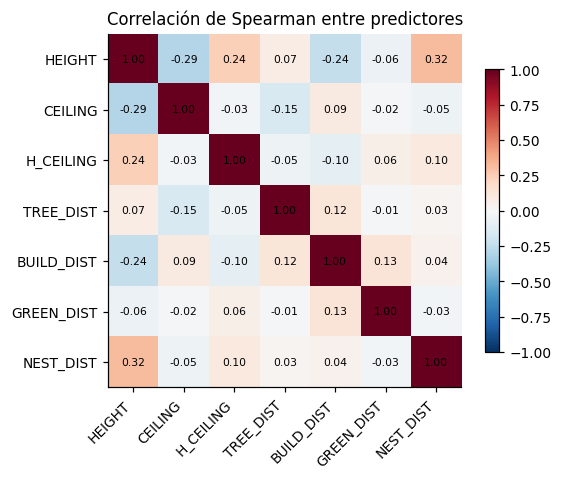

In [16]:
# Correlaciones de Spearman entre predictores numéricos
corr = X[NUM].corr(method="spearman")
fig, ax = plt.subplots(figsize=(5.4,4.4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(NUM))); ax.set_xticklabels(NUM, rotation=45, ha="right")
ax.set_yticks(range(len(NUM))); ax.set_yticklabels(NUM); ax.grid(False)
for i in range(len(NUM)):
    for j in range(len(NUM)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, shrink=.8); ax.set_title("Correlación de Spearman entre predictores")
plt.tight_layout(); plt.show()

---
# Fase 2 — Entrenamiento del modelo de caja negra

Partición estratificada 75/25 que conserva la proporción 1:2 de las clases, `Pipeline` con One-Hot Encoding para las tres variables categóricas y `RandomForestClassifier`. Se usa `class_weight="balanced_subsample"` para compensar el desbalance y `min_samples_leaf=2` como regularización mínima frente al tamaño de muestra.

In [17]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RS)
print("Entrenamiento:", Xtr.shape, dict(ytr.value_counts()))
print("Prueba:       ", Xte.shape, dict(yte.value_counts()))

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), CAT)],
    remainder="passthrough", verbose_feature_names_out=False)

rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                            class_weight="balanced_subsample", random_state=RS, n_jobs=-1)

pipe = Pipeline([("pre", pre), ("rf", rf)]).fit(Xtr, ytr)
feat = pre.get_feature_names_out().tolist()
print("\nVariables tras One-Hot:", len(feat)); print(feat)

Entrenamiento: (72, 10) {0: np.int64(48), 1: np.int64(24)}
Prueba:        (24, 10) {0: np.int64(16), 1: np.int64(8)}

Variables tras One-Hot: 17
['CONCEAL_A', 'CONCEAL_B', 'CONCEAL_C', 'B_ASPECT_A', 'B_ASPECT_B', 'B_ASPECT_C', 'B_ASPECT_D', 'B_STRUCT_A', 'B_STRUCT_B', 'B_STRUCT_C', 'HEIGHT', 'CEILING', 'H_CEILING', 'TREE_DIST', 'BUILD_DIST', 'GREEN_DIST', 'NEST_DIST']


Accuracy       0.750
F1 (clase P)   0.625
ROC AUC        0.797

                precision    recall  f1-score   support

 Ausencia (A)       0.81      0.81      0.81        16
Presencia (P)       0.62      0.62      0.62         8

     accuracy                           0.75        24
    macro avg       0.72      0.72      0.72        24
 weighted avg       0.75      0.75      0.75        24



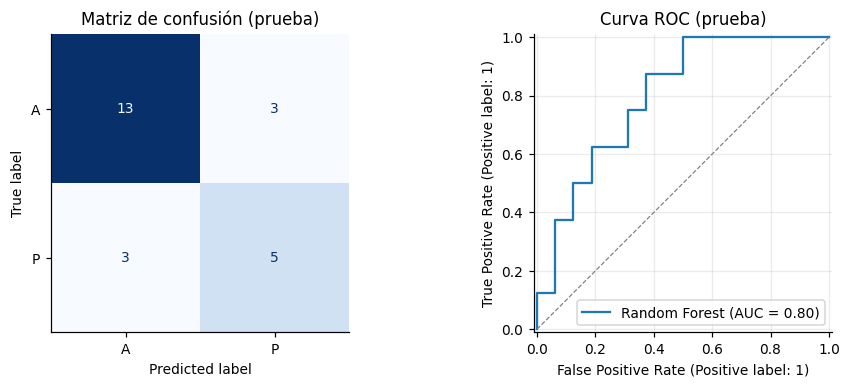

In [18]:
proba = pipe.predict_proba(Xte)[:, 1]
pred  = pipe.predict(Xte)
cm = confusion_matrix(yte, pred)

metricas = {"Accuracy": accuracy_score(yte, pred),
            "F1 (clase P)": f1_score(yte, pred),
            "ROC AUC": roc_auc_score(yte, proba)}
for k, v in metricas.items(): print(f"{k:14s} {v:.3f}")
print("\n", classification_report(yte, pred, target_names=["Ausencia (A)","Presencia (P)"]))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ConfusionMatrixDisplay(cm, display_labels=["A","P"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Matriz de confusión (prueba)"); ax[0].grid(False)
RocCurveDisplay.from_predictions(yte, proba, ax=ax[1], name="Random Forest")
ax[1].plot([0,1],[0,1],"--",c="grey",lw=.8); ax[1].set_title("Curva ROC (prueba)")
plt.tight_layout(); plt.show()

In [19]:
# Validación cruzada estratificada sobre el total: el conjunto de prueba tiene solo 24 casos
cv = StratifiedKFold(5, shuffle=True, random_state=RS)
for m in ["roc_auc", "f1", "accuracy"]:
    s = cross_val_score(pipe, X, y, cv=cv, scoring=m)
    print(f"CV 5-fold {m:9s}: {s.mean():.3f} ± {s.std():.3f}")

CV 5-fold roc_auc  : 0.803 ± 0.133
CV 5-fold f1       : 0.562 ± 0.129
CV 5-fold accuracy : 0.719 ± 0.082


### Interpretación de las métricas

El modelo alcanza **accuracy 0.750, F1 0.625 y ROC AUC 0.797** en el conjunto de prueba, con una validación cruzada de 5 pliegues que confirma el orden de magnitud (**AUC 0.803 ± 0.133**) pero con una desviación muy alta.

Tres lecturas obligadas por el diseño:

1. **El desbalance 32/64 hace engañosa la accuracy.** Un clasificador trivial que prediga siempre "ausencia" obtiene 0.667. El 0.750 observado supera esa línea base por poco más de dos casos; el ROC AUC, insensible a la prevalencia, es la métrica informativa aquí.
2. **La clase minoritaria se predice peor.** La matriz de confusión muestra 5 de 8 presencias recuperadas (recall 0.62) frente a 13 de 16 ausencias (0.81): el modelo es conservador hacia la clase mayoritaria pese al reponderamiento.
3. **El conjunto de prueba tiene 24 observaciones.** Un solo caso reclasificado mueve la accuracy en ~4 puntos porcentuales. La desviación de ±0.133 en el AUC de validación cruzada indica que **cualquier ranking de importancia derivado de este modelo debe leerse como orientativo, no como estimación estable**. Esta fragilidad es en sí misma un límite de la explicación, no solo del desempeño.

---
# Fase 3 — Explicación global y local

## 3.1 Explicación global con SHAP y comparación con la importancia por permutación

In [20]:
Xtr_t, Xte_t = pre.transform(Xtr), pre.transform(Xte)

expl_cond = shap.TreeExplainer(pipe.named_steps["rf"])   # tree_path_dependent (condicional)
sv_cond = expl_cond(Xte_t, check_additivity=False)
sv1 = sv_cond.values[:, :, 1] if sv_cond.values.ndim == 3 else sv_cond.values

glob = pd.Series(np.abs(sv1).mean(0), index=feat).sort_values(ascending=False)
print("Ranking global por media |SHAP| (atribución condicional):")
print(glob.round(4).to_string())

Ranking global por media |SHAP| (atribución condicional):
HEIGHT        0.0815
CONCEAL_A     0.0585
CEILING       0.0481
CONCEAL_C     0.0422
NEST_DIST     0.0402
BUILD_DIST    0.0385
H_CEILING     0.0247
TREE_DIST     0.0190
B_ASPECT_D    0.0099
GREEN_DIST    0.0098
B_STRUCT_A    0.0095
B_ASPECT_A    0.0066
B_ASPECT_C    0.0062
CONCEAL_B     0.0033
B_STRUCT_C    0.0030
B_ASPECT_B    0.0016
B_STRUCT_B    0.0004


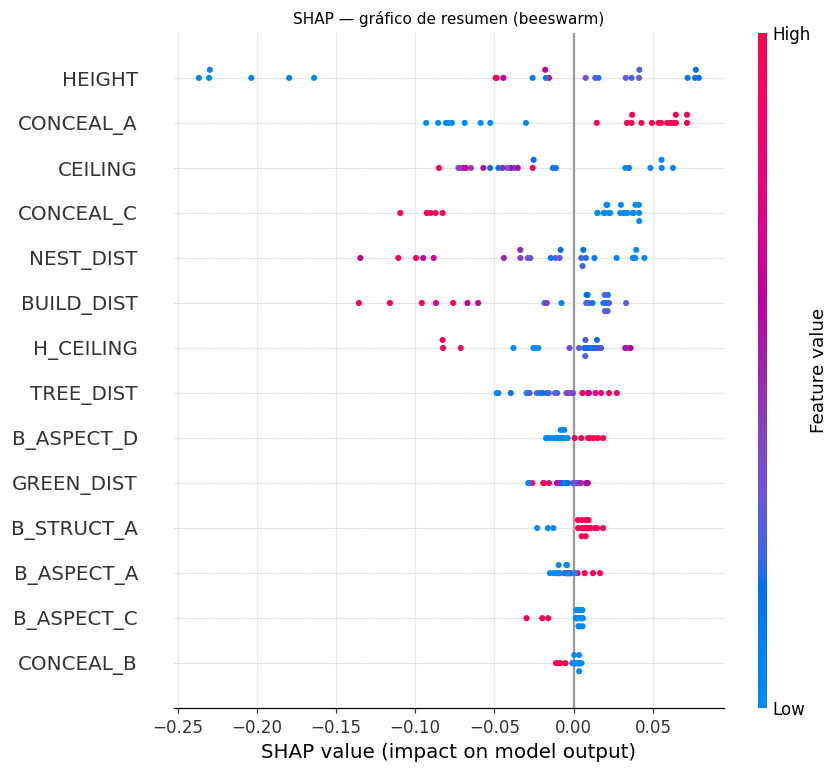

In [21]:
shap.summary_plot(sv1, Xte_t, feature_names=feat, max_display=14, show=False)
plt.title("SHAP — gráfico de resumen (beeswarm)", fontsize=10); plt.tight_layout(); plt.show()



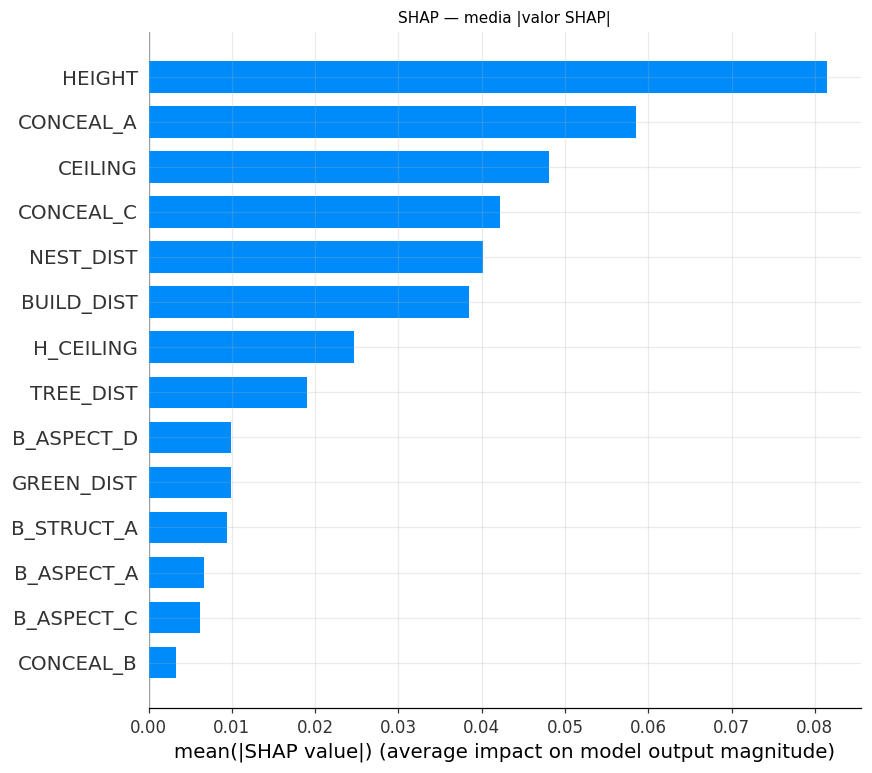

In [22]:
shap.summary_plot(sv1, Xte_t, feature_names=feat, plot_type="bar", max_display=14, show=False)
plt.title("SHAP — media |valor SHAP|", fontsize=10); plt.tight_layout(); plt.show()

In [ ]:
# Importancia por permutación sobre el pipeline completo (variables originales, métrica ROC AUC)
pi = permutation_importance(pipe, Xte, yte, n_repeats=50, random_state=RS, scoring="roc_auc")
pis = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)

# SHAP agregado a la variable original, para que ambos rankings sean comparables
def agregar(vals):
    s = pd.Series(np.abs(vals).mean(0), index=feat)
    return pd.Series({col: s[[f for f in feat if f == col or f.startswith(col + "_")]].sum()
                      for col in X.columns})

comp = pd.DataFrame({"SHAP (media |SHAP|)": agregar(sv1),
                     "Permutación (ΔAUC)": pis}).sort_values("SHAP (media |SHAP|)", ascending=False)
comp["rank_SHAP"] = comp["SHAP (media |SHAP|)"].rank(ascending=False).astype(int)
comp["rank_perm"] = comp["Permutación (ΔAUC)"].rank(ascending=False).astype(int)
print(comp.round(4).to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
o = comp.index[::-1]; ypos = np.arange(len(o)); w = .4
ax.barh(ypos-w/2, comp.loc[o,"SHAP (media |SHAP|)"]/comp["SHAP (media |SHAP|)"].max(), w, label="SHAP (normalizada)")
ax.barh(ypos+w/2, comp.loc[o,"Permutación (ΔAUC)"]/comp["Permutación (ΔAUC)"].max(), w, label="Permutación (normalizada)")
ax.set_yticks(ypos); ax.set_yticklabels(o); ax.axvline(0, c="k", lw=.8)
ax.set_title("SHAP vs. importancia por permutación"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Coincidencias y diferencias entre ambos métodos

**Coinciden** en la cúspide del ranking: `HEIGHT`, `CEILING` y `BUILD_DIST` son importantes bajo los dos criterios, y `GREEN_DIST` es marginal en ambos. Esta concordancia es la evidencia más sólida de que la altura del sitio y la protección vertical son las señales reales que el modelo utiliza.

**Discrepan de forma reveladora en dos variables:**

- **`NEST_DIST`** es la 4.ª variable por SHAP (0.040) pero recibe una importancia por permutación **negativa** (−0.013): permutarla *mejora* el AUC en prueba. La lectura correcta es que SHAP mide **cuánto usa el modelo la variable**, mientras que la permutación mide **cuánto aporta la variable al desempeño fuera de muestra**. El modelo se apoya intensamente en `NEST_DIST`, pero ese apoyo no se traduce en poder predictivo generalizable: es un patrón ajustado al conjunto de entrenamiento. Confirma la sospecha planteada en la Fase 1 sobre la fuga espacial.
- **`CONCEAL`** es la variable de mayor peso agregado por SHAP (0.104, sumando sus tres categorías) pero cae al 7.º lugar por permutación (0.003). Al permutar `CONCEAL` el desempeño apenas se mueve porque su información **está duplicada en otras variables** —principalmente en `B_STRUCT` y `HEIGHT`—, de modo que el bosque la recupera por otra vía. Esto es exactamente el comportamiento esperado ante predictores redundantes y se documenta cuantitativamente en la Fase 4.

La divergencia no indica que un método esté equivocado: responden preguntas distintas, y leerlos juntos es lo que permite detectar el proxy.

## 3.2 Explicación local: SHAP y LIME sobre el mismo sitio

In [ ]:
# Sitio de prueba con presencia observada y mayor probabilidad estimada
cands = [i for i in range(len(yte)) if yte.iloc[i] == 1]
idx = max(cands, key=lambda i: proba[i])

print(f"Sitio seleccionado — índice original: {Xte.index[idx]}")
print(f"Clase observada:    {'Presencia (P)' if yte.iloc[idx]==1 else 'Ausencia (A)'}")
print(f"Probabilidad estimada P(nido): {proba[idx]:.3f}")
print(f"Clase predicha:     {'Presencia (P)' if pred[idx]==1 else 'Ausencia (A)'}  -> clasificación correcta")
print("\nCaracterísticas del sitio:"); print(Xte.iloc[idx].to_string())

In [ ]:
# SHAP intervencional. Siguiendo el cuaderno de la sección, la distribución de
# referencia es el conjunto de entrenamiento completo, no una submuestra.
masker = shap.maskers.Independent(Xtr_t, max_samples=len(Xtr_t))

expl_int = shap.TreeExplainer(
    pipe.named_steps["rf"],
    data=masker,                          # distribución de referencia
    feature_perturbation="interventional",# función de valor intervencional
    model_output="probability")           # explica la probabilidad predicha

sv_int = expl_int(Xte_t)
svi1 = sv_int.values[:, :, 1] if sv_int.values.ndim == 3 else sv_int.values
base_val = float(np.array(expl_int.expected_value).ravel()[-1])

local = pd.Series(svi1[idx], index=feat).sort_values(key=np.abs, ascending=False)
print(f"Valor base (probabilidad media): {base_val:.4f}")
print(f"Suma de atribuciones + base:     {base_val + svi1[idx].sum():.4f}  (= probabilidad predicha)\n")
print(local.head(10).round(4).to_string())

In [ ]:
shap.plots.waterfall(shap.Explanation(values=svi1[idx], base_values=base_val,
                     data=Xte_t[idx], feature_names=feat), max_display=12, show=False)
plt.title("SHAP local — descomposición en cascada", fontsize=10); plt.tight_layout(); plt.show()

In [ ]:
# LIME sobre el mismo sitio. Siguiendo el cuaderno de la sección se mantiene
# discretize_continuous=False, de modo que los pesos son directamente comparables
# con los valores SHAP y no dependen de los cortes de discretización.
cat_maps = {col: sorted(X[col].unique()) for col in CAT}
cols = list(X.columns); cat_idx = [cols.index(col) for col in CAT]

def codificar(d):
    d = d.copy()
    for col in CAT: d[col] = d[col].map({v: i for i, v in enumerate(cat_maps[col])})
    return d.values.astype(float)

def predict_fn(arr):
    d = pd.DataFrame(arr, columns=cols)
    for col in CAT:
        d[col] = d[col].round().astype(int).clip(0, len(cat_maps[col])-1).map(dict(enumerate(cat_maps[col])))
    return pipe.predict_proba(d[cols])

lime_exp = LimeTabularExplainer(
    codificar(Xtr), feature_names=cols, class_names=["Ausencia","Presencia"],
    categorical_features=cat_idx,
    categorical_names={cols.index(col): [str(v) for v in cat_maps[col]] for col in CAT},
    discretize_continuous=False, mode="classification", random_state=RS)

le = lime_exp.explain_instance(codificar(Xte)[idx], predict_fn,
                               num_features=len(cols), num_samples=5000, labels=(1,))

# Fidelidad del sustituto local: ¿reproduce la predicción del Random Forest?
pred_local = float(np.asarray(le.local_pred).reshape(-1)[0])
print(f"Predicción Random Forest : {proba[idx]:.4f}")
print(f"Predicción local de LIME : {pred_local:.4f}")
print(f"Fidelidad local (R²)     : {le.score:.4f}\n")
for f, w in le.as_list(label=1): print(f"  {f:24s} {w:+.4f}")

### 3.2.1 LIME agregado: una vista pseudo-global

LIME es por construcción un método local (Ribeiro et al., 2016). Para obtener una vista global comparable
con SHAP se aplica la lógica de *submodular pick*: se explican todas las instancias de prueba y se promedia
el valor absoluto del peso asignado a cada variable. El resultado permite contrastar los tres métodos
—SHAP, LIME y permutación— sobre la misma escala.

In [ ]:
# Explicaciones LIME para todo el conjunto de prueba
Xte_enc = codificar(Xte)
pesos = {c: [] for c in cols}
for k in range(len(Xte)):
    e = lime_exp.explain_instance(Xte_enc[k], predict_fn, num_features=len(cols), num_samples=1500)
    # e.as_map()[1] entrega (índice_de_variable, peso) en el espacio original
    for j, w in e.as_map()[1]:
        pesos[cols[j]].append(abs(w))

lime_glob = pd.Series({c: np.mean(v) if v else 0.0 for c, v in pesos.items()}).sort_values(ascending=False)
print("LIME agregado sobre las 24 instancias de prueba (media |peso|):")
print(lime_glob.round(4).to_string())

In [ ]:
# Comparación de los tres métodos en escala normalizada
tres = pd.DataFrame({
    "SHAP":        agregar(sv1) / agregar(sv1).max(),
    "LIME":        lime_glob / lime_glob.max(),
    "Permutación": pis / pis.max()}).sort_values("SHAP", ascending=False)
print(tres.round(3).to_string())
print("\nCorrelación de Spearman entre rankings:")
print(tres.corr(method="spearman").round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
o = tres.index[::-1]; yp = np.arange(len(o)); w = .26
for k, (col, c) in enumerate(zip(["SHAP","LIME","Permutación"], ["#1A9E8F","#9E0142","#C9CDD6"])):
    ax.barh(yp + (k-1)*w, tres.loc[o, col], w, color=c, label=col)
ax.set_yticks(yp); ax.set_yticklabels(o); ax.axvline(0, c="#5A5F6A", lw=.9)
ax.set_xlabel("Importancia relativa (normalizada por el máximo de cada método)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.set_title("Tres métodos de importancia global sobre la misma escala", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Lectura.** Los rankings de SHAP y LIME son casi idénticos (ρ de Spearman = **0.952**), mientras que
cada uno de ellos frente a la importancia por permutación cae a **0.248** y **0.224** respectivamente. El
contraste es nítido y sostiene el argumento central del cuaderno: SHAP y LIME coinciden porque ambos son
métodos de atribución sobre la función aprendida y comparten el sesgo hacia las variables que el modelo
efectivamente lee. La permutación, que mide aporte predictivo fuera de muestra, es la que se separa —y es esa
separación, no la coincidencia entre SHAP y LIME, la que revela los proxies.

El acuerdo entre dos explicadores no es, por tanto, evidencia de validez: dos métodos pueden coincidir con
precisión en describir el mismo atajo estadístico. `CONCEAL` encabeza ambos rankings de atribución y recibe
una importancia por permutación de apenas 0.022; `NEST_DIST` es cuarta en ambos y su permutación es negativa.

### Comparación de ambas explicaciones locales

| | SHAP intervencional | LIME |
|---|---|---|
| 1.º | `HEIGHT` (+0.101) | `CONCEAL = A` (+0.185) |
| 2.º | `CONCEAL_A` (+0.076) | `NEST_DIST` (−0.043) |
| 3.º | `CEILING` (+0.073) | `CEILING` (−0.034) |
| 4.º | `CONCEAL_C` (+0.049) | `HEIGHT` (+0.032) |
| Predicción reproducida | 0.823 (exacta, por eficiencia) | 0.478 |
| Fidelidad local | garantizada por el axioma | R² = 0.574 |

**La fidelidad cambia la lectura.** Antes de comparar rankings hay que preguntar si cada explicación
describe fielmente al modelo en ese punto. SHAP satisface el axioma de eficiencia: sus atribuciones suman
exactamente la diferencia entre la probabilidad predicha (0.823) y el valor base (0.368). El sustituto
lineal de LIME, en cambio, alcanza **R² = 0.574** y predice **0.478** donde el modelo predice 0.823.

Esa brecha invalida la lectura detallada de LIME para este sitio. Sus pesos asignan signo **negativo** a
`NEST_DIST` y `CEILING`, opuesto al de SHAP; con una aproximación local tan pobre, esa discrepancia no es
evidencia sobre el ave ni sobre el modelo, sino ruido del sustituto. Lo que ambos métodos sí sostienen es
el factor dominante: `CONCEAL = A` y una altura moderada empujan la probabilidad al alza.

La lección metodológica es que **la fidelidad, y no la coincidencia entre métodos, es el criterio para
confiar en una explicación local**. Dos explicaciones pueden coincidir siendo ambas infieles, o diferir
solo porque una de ellas no aproxima bien la superficie de decisión en esa vecindad.

## 3.3 Dependencia parcial (PDP), curvas individuales (ICE) y ALE

In [ ]:
for v in ["HEIGHT", "NEST_DIST"]:
    fig, ax = plt.subplots(figsize=(5.2, 3.8))
    PartialDependenceDisplay.from_estimator(
        pipe, Xte, [v], kind="both", ax=ax,
        ice_lines_kw={"alpha": .3, "color": "grey", "lw": .8},
        pd_line_kw={"color": "crimson", "lw": 2.4, "label": "PDP (promedio)"})
    ax.set_ylabel("P(nido) parcial"); ax.set_title(f"PDP + ICE — {v}", fontsize=10)
    plt.tight_layout(); plt.show()

In [ ]:
# PDP para variables categóricas: probabilidad media al fijar cada categoría
# en todo el conjunto de prueba
print("PDP categórico — probabilidad media de presencia:")
for cvar in CAT:
    filas = []
    for k in sorted(X[cvar].unique()):
        Xm = Xte.copy(); Xm[cvar] = k
        filas.append({cvar: k, "P(nido) media": pipe.predict_proba(Xm)[:, 1].mean()})
    print(pd.DataFrame(filas).round(3).to_string(index=False), "\n")

In [ ]:
# ALE con PyALE, la misma librería del cuaderno de la sección
from PyALE import ale

class ModeloProbabilidad:
    """Adapta el Pipeline para que ALE explique P(nido)."""
    def predict(self, X_new): return pipe.predict_proba(X_new)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, v in zip(axes, ["HEIGHT", "NEST_DIST"]):
    r = ale(X=Xte, model=ModeloProbabilidad(), feature=[v],
            grid_size=8, include_CI=False, plot=False)
    ax.plot(r.index, r["eff"], marker="o", color="#1A9E8F")
    ax.axhline(0, ls="--", c="#C9CDD6", lw=.9)
    ax.set_xlabel(v); ax.set_ylabel("ALE (probabilidad centrada)")
    ax.set_title(f"ALE — {v}", fontsize=10, loc="left")
    print(f"ALE {v}:\n{r.round(4).to_string()}\n")
plt.tight_layout(); plt.show()

**¿Por qué ALE además de PDP?** El PDP promedia sobre la distribución marginal de las demás variables y, cuando hay dependencia entre predictores, evalúa el modelo en combinaciones que no existen en los datos (por ejemplo, un sitio de 1500 cm de altura con `B_STRUCT = A`, cuando la altura y el tipo de soporte están fuertemente asociados: prueba de Kruskal-Wallis p < 0.001, Fase 4). ALE evita esa extrapolación porque acumula diferencias **locales** dentro de intervalos poblados de la variable. La comparación entre ambas curvas sirve aquí como diagnóstico: donde coinciden, la dependencia no está distorsionando la lectura; donde divergen, el PDP está extrapolando.

### ¿Qué patrones dice el modelo que utiliza?

1. **Altura moderada, no máxima.** La probabilidad es alta en el rango ~280–380 cm y cae para sitios muy bajos (< 250 cm, expuestos a perturbación) y muy altos (> 600 cm). La forma es no monótona, algo que un modelo lineal habría ocultado.
2. **Protección vertical.** Distancias al techo cortas (`CEILING` bajo, mediana 29.5 cm en presencias frente a 46.5 en ausencias) elevan la probabilidad: el sitio está cubierto por arriba.
3. **Ocultamiento frontal y lateral.** `CONCEAL = A` es la categoría con mayor probabilidad condicional de presencia (0.480 frente a 0.211 en B y 0.148 en C).
4. **Distancia decreciente al nido más cercano.** El ALE de `NEST_DIST` es marcadamente decreciente (+0.085 en el primer nodo, −0.081 alrededor de 279 m). El modelo aprendió agregación espacial. **Este es el patrón que menos debe interpretarse sustantivamente**: es un artefacto del diseño, no una preferencia de hábitat.

### Extensión opcional — Contrafactual accionable

Un cambio contrafactual es **accionable** si puede realizarse en el contexto real. En este problema la
distinción es nítida y ecológicamente significativa:

| No accionables | Accionables mediante manejo urbano |
|---|---|
| `B_ASPECT` (orientación del edificio) | `CONCEAL` (añadir o retirar un panel lateral) |
| `TREE_DIST`, `GREEN_DIST`, `BUILD_DIST` (paisaje) | `CEILING`, `H_CEILING` (geometría de la repisa) |
| `NEST_DIST` (descendiente del resultado) | `HEIGHT` (reubicación del soporte) |

Restringir la búsqueda a las variables accionables evita contrafactuales vacíos, del tipo «si el edificio
mirara al norte». La lectura válida sigue siendo sobre el modelo: si recibiera esos valores, produciría
otra predicción. No afirma que realizar el cambio modifique la anidación real (Wachter et al., 2017).

In [ ]:
import dice_ml

ACCIONABLES = ["CONCEAL", "CEILING", "H_CEILING", "HEIGHT"]

train_dice = Xtr.copy(); train_dice["nido"] = ytr.to_numpy()
dice_data  = dice_ml.Data(dataframe=train_dice, continuous_features=NUM, outcome_name="nido")
dice_model = dice_ml.Model(model=pipe, backend="sklearn", model_type="classifier")
dice       = dice_ml.Dice(dice_data, dice_model, method="random")

base = Xte.iloc[[idx]].copy()
print(f"Sitio original — P(nido) = {pipe.predict_proba(base)[:,1][0]:.3f} (presencia predicha)\n")
try:
    cf = dice.generate_counterfactuals(
        query_instances=base, total_CFs=3, desired_class=0,
        features_to_vary=ACCIONABLES, random_seed=RS)
    cf.visualize_as_dataframe(show_only_changes=True)
except Exception as e:
    print("DiCE no encontró contrafactuales:", e)

# Contrafactual dirigido: variación de una sola condición accionable
print("\nVariación de CONCEAL manteniendo todo lo demás fijo:")
for cval, etq in [("A","invisible de frente y lados"), ("B","visible de un lado"), ("C","visible de frente")]:
    t = base.copy(); t["CONCEAL"] = cval
    print(f"  CONCEAL={cval} ({etq:28s}): {pipe.predict_proba(t)[:,1][0]:.3f}")

**Lo que devuelve la búsqueda.** Los tres contrafactuales hallados por DiCE coinciden en un punto:
**todos exigen `CONCEAL = C`**. Ninguno logra invertir la predicción manipulando únicamente la geometría
de la repisa. Dos de ellos añaden además una altura extrema (1031 y 1008 cm, dentro del rango observado
pero muy lejos de los 299 cm del sitio) y el tercero lleva `CEILING` a 130 cm.

La variación dirigida de una sola condición confirma la gradación monótona: 0.823 con ocultamiento total,
0.657 con visibilidad lateral y 0.490 expuesto de frente. El ocultamiento es, por tanto, la única palanca
accionable que por sí sola cruza el umbral de decisión, y lo hace por un margen estrecho (0.490 frente a
0.500), lo que refuerza la lectura de fragilidad del modelo.

**Advertencia.** Que DiCE necesite cambios de gran magnitud en las demás variables accionables es
información sobre la superficie de decisión del modelo, no sobre el ave. Y que `CONCEAL` aparezca en los
tres contrafactuales no demuestra que el ocultamiento cause la anidación: la redundancia con `B_STRUCT`
documentada en la Fase 4 sigue impidiendo esa conclusión.

---
# Fase 4 — SHAP intervencional y límites de la explicación

## 4.1 Atribución condicional frente a atribución intervencional

`tree_path_dependent` recorre los caminos del árbol usando las frecuencias de entrenamiento y, por tanto, **distribuye crédito a variables correlacionadas con la que realmente usa el árbol**: es una atribución *condicional* que respeta la distribución conjunta observada. La atribución **intervencional** rompe esa dependencia sustituyendo valores desde una distribución de fondo (`background`), de modo que el crédito se asigna a la variable que el modelo efectivamente lee. Es la variante alineada con los valores de Shapley "verdaderos" del modelo y la que debe usarse cuando el objetivo es auditar el mecanismo interno.

In [ ]:
glob_int = pd.Series(np.abs(svi1).mean(0), index=feat).sort_values(ascending=False)

A, B = agregar(sv1), agregar(svi1)       # agregadas a la variable original
print(f"Suma de |SHAP| observacional : {A.sum():.4f}")
print(f"Suma de |SHAP| intervencional: {B.sum():.4f}")
print(f"Contracción global de escala : {100*(B.sum()-A.sum())/A.sum():.1f} %\n")

# La caída absoluta mezcla esa contracción global con la redistribución de crédito.
# La lectura correcta es la participación relativa de cada variable en el total.
comparacion = pd.DataFrame({
    "obs": A, "int": B,
    "obs_rel": A/A.sum(), "int_rel": B/B.sum()})
comparacion["cambio_rel_%"] = 100*(comparacion["int_rel"]-comparacion["obs_rel"])/comparacion["obs_rel"]
comparacion["caida_abs_%"]  = 100*(B-A)/A
print(comparacion.sort_values("int", ascending=False).round(4).to_string())

In [ ]:
shap.summary_plot(svi1, Xte_t, feature_names=feat, max_display=14, show=False)
plt.title("SHAP intervencional — gráfico de resumen", fontsize=10); plt.tight_layout(); plt.show()

**Una precaución antes de leer el contraste.** Las dos atribuciones no están en la misma escala: la suma
de |SHAP| se contrae un **8.3 %** al pasar a la versión intervencional. Por eso la *caída absoluta* de cada
variable mezcla dos cosas distintas —ese cambio global de escala y la redistribución de crédito entre
variables— y sobreestima sistemáticamente el efecto de romper las dependencias. La lectura correcta es la
**participación relativa** de cada variable en el total.

Leído así, el resultado es el siguiente:

- **`GREEN_DIST` pierde un 15.9 % de su participación** y **`B_ASPECT` un 7.8 %**: parte de su importancia
  aparente era prestada por correlación con otras variables.
- `CEILING` y `NEST_DIST` ceden alrededor del 5.6 % cada una.
- **`CONCEAL` gana un 7.7 %** y `H_CEILING` un 6.5 %.

El caso de referencia del curso —un modelo de puntaje Saber 11, donde la importancia del sector del colegio
cae cerca de un 28 % al pasar a la atribución intervencional— sirve de escala de comparación: aquí ninguna
variable alcanza ese nivel, de modo que la contaminación por correlación es real pero más moderada.

**El resultado más informativo es inverso al que anticipaba el diagnóstico de redundancia.** Que `CONCEAL`
*gane* participación al romper las dependencias indica que el modelo lee genuinamente el ocultamiento, y no
lo usa como mero vehículo de `B_STRUCT`. La redundancia entre ambas (V de Cramér = 0.482) sigue siendo real
y sigue impidiendo separar sus efectos, pero el problema no es que la atribución de `CONCEAL` sea prestada:
es que los datos no contienen la variación necesaria para saber cuál de las dos opera.

## 4.2 Diagnóstico de proxies: dependencia entre predictores

In [ ]:
def cramers_v(a, b):
    ct = pd.crosstab(a, b); chi2 = chi2_contingency(ct)[0]; n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print("V de Cramér entre variables categóricas:")
for i, a in enumerate(CAT):
    for b in CAT[i+1:]:
        print(f"  {a} – {b}: {cramers_v(X[a], X[b]):.3f}")

print("\nAsociación numérica ~ categórica (Kruskal-Wallis, se listan p < 0.05):")
for cvar in CAT:
    for nvar in NUM:
        grupos = [X.loc[X[cvar]==k, nvar] for k in X[cvar].unique()]
        p = kruskal(*grupos)[1]
        if p < 0.05: print(f"  {nvar:11s} ~ {cvar:9s}: p = {p:.4f}")

In [ ]:
print("Tabla de contingencia CONCEAL × B_STRUCT (conteos):")
print(pd.crosstab(X["CONCEAL"], X["B_STRUCT"]).to_string())
print("\nProporciones por fila:")
print(pd.crosstab(X["CONCEAL"], X["B_STRUCT"], normalize="index").round(3).to_string())
print(f"\nCorrelación de Spearman TREE_DIST – GREEN_DIST: {X[['TREE_DIST','GREEN_DIST']].corr('spearman').iloc[0,1]:.3f}")

### Proxies identificados

**1. `CONCEAL` es en buena medida un proxy de `B_STRUCT` (V de Cramér = 0.482).** La tabla de contingencia lo muestra con claridad: de los 50 sitios con ocultamiento total (`CONCEAL = A`), 44 son avisos publicitarios (`B_STRUCT = A`); de los 27 sitios expuestos de frente (`CONCEAL = C`), 15 son balcones y solo 5 avisos. **El ocultamiento no es una propiedad independiente del sitio: es una consecuencia casi determinista del tipo de estructura.** Cuando SHAP atribuye peso a `CONCEAL_A`, no puede distinguirse si el modelo está capturando el ocultamiento *per se* o simplemente el hecho de que el sitio es un aviso publicitario —que además difiere en altura, material, estabilidad y accesibilidad humana. Este es el hallazgo central del diagnóstico de proxies, y afecta directamente a la pregunta causal de la Fase 5.

**2. `HEIGHT` está fuertemente asociada tanto a `CONCEAL` como a `B_STRUCT` (Kruskal-Wallis p < 0.001 en ambos casos).** La altura funciona a la vez como condición del micrositio y como marcador del tipo de estructura. Su primer lugar en el ranking global es, por tanto, parcialmente atribuible a que resume información estructural.

**3. `NEST_DIST` es el proxy más problemático,** por las razones ya expuestas: no describe el sitio sino la configuración espacial de los nidos vecinos, y además está asociada a `B_STRUCT` (p < 0.001) y a `HEIGHT` (ρ = 0.315). Su importancia por permutación negativa confirma que el modelo la usa sin obtener capacidad predictiva generalizable de ella.

**4. La hipótesis `TREE_DIST` – `GREEN_DIST` de la guía no se sostiene en estos datos.** La correlación de Spearman entre ambas es **−0.015**, esencialmente nula: en Karaj, la distancia al árbol más cercano y la distancia a la zona verde capturan escalas espaciales distintas (árbol aislado de calle frente a parque urbano). Es un resultado negativo útil: la redundancia relevante no está en el paisaje sino en el bloque estructural `CONCEAL`–`B_STRUCT`–`HEIGHT`.

### Taxonomía de los límites, aplicada a este conjunto

La sección distingue varias estructuras que impiden leer causalmente una explicación. Las cuatro aparecen
en este problema:

| Estructura | Realización en estos datos |
|---|---|
| **Confusión** (Z → A, Z → Y) | La perturbación humana no observada puede influir a la vez sobre el tipo de estructura disponible y sobre la presencia de nido. |
| **Mediación** (A → M → Y) | Modificar físicamente `CONCEAL` altera `CEILING` y `H_CEILING`; parte del efecto del ocultamiento pasaría por ellas, que no serían controles legítimos. |
| **Colisionador** (A → C ← U) | `NEST_DIST` es descendiente del resultado: condicionar sobre ella induce asociaciones espurias. |
| **Variable posterior al evento** | `NEST_DIST` otra vez: los nidos vecinos solo existen una vez ocurrida la temporada que se quiere predecir. Es fuga de información, y explica su importancia por permutación negativa. |

### Por qué la atribución del modelo no demuestra causalidad

Aunque la atribución intervencional rompe la dependencia estadística **entre las entradas del modelo**, sigue siendo una afirmación sobre **la función aprendida**, no sobre el proceso que generó los datos. Tres razones:

1. **La intervención es sobre el modelo, no sobre el mundo.** `shap.TreeExplainer(..., feature_perturbation="interventional")` responde: *¿cómo cambia la salida de este bosque si sustituyo esta entrada?* La pregunta causal es: *¿cómo cambia la anidación si modifico esta característica del sitio?* Son dos sistemas distintos, y solo el primero está accesible.
2. **Confusión no observada.** Variables no registradas —presión de depredadores (gatos, córvidos), tránsito peatonal, disponibilidad de agua, historial de retirada de nidos por mantenimiento— pueden causar simultáneamente la configuración del sitio y la presencia de nido. Ninguna atribución construida solo con las diez covariables disponibles puede desconfundir un efecto de este tipo.
3. **Redundancia irreducible.** Con V de Cramér de 0.482 entre `CONCEAL` y `B_STRUCT`, **ningún método de atribución puede separar sus efectos**, porque los datos no contienen la variación necesaria: no hay balcones ocultos ni avisos expuestos en cantidad suficiente. El problema no es del método sino del diseño muestral, y por eso no se resuelve cambiando de explicador.

A esto se suma un límite práctico: con 24 casos de prueba y un AUC de validación cruzada de 0.803 ± 0.133, el propio ranking de atribuciones es inestable ante cambios de partición.

## 4.3 Qué afirma válidamente cada método

En SHAP, «intervencional» describe **cómo se construye la función de valor**: fija algunas entradas del
modelo y toma las demás de una distribución de referencia. Esa operación modifica entradas del modelo; no
identifica un efecto causal en el fenómeno real.

| Método | Lectura válida | Lectura **no** válida |
|---|---|---|
| SHAP local | Para este sitio, la variable contribuye a subir o bajar la probabilidad **predicha**. | Esa variable causa el cambio en la presencia real de nido. |
| SHAP global | La variable participa de forma importante en las predicciones del modelo. | La variable tiene un efecto causal promedio grande. |
| LIME | Dirección e importancia local en esa vecindad, **si la fidelidad lo respalda**. | Los pesos son efectos causales o parámetros poblacionales. |
| Permutación | El modelo depende de esa variable para mantener su desempeño. | Intervenir la variable produciría un cambio equivalente en la anidación. |
| PDP / ICE | El modelo predice distinto al reemplazar valores de la variable. | El resultado real cambiaría así bajo una intervención. |
| ALE | Cambios locales de predicción en regiones con datos, sin extrapolar. | Trabajar en regiones observadas convierte el resultado en causal. |
| Contrafactual | Si el modelo recibiera esos valores, produciría otra predicción. | Realizar esos cambios modificaría necesariamente el resultado. |

Permutar una columna es una operación sobre la tabla, no una intervención sobre el mundo. Esta tabla es el
criterio que se aplica en la Fase 5 para separar lo que este estudio puede afirmar de lo que no.

---
# Fase 5 — Formulación de la pregunta causal

## 5.1 La pregunta que las explicaciones no responden

> **¿Cuál sería la probabilidad de anidación de la tórtola senegalesa en un sitio urbano de Karaj si se modificara su nivel de ocultamiento de expuesto de frente (`CONCEAL = C`) a invisible de frente y lados (`CONCEAL = A`), manteniendo constantes la altura, el tipo de soporte, la orientación y las distancias al entorno?**

En notación de operador de intervención, se busca contrastar
$$P\big(\text{nido}=1 \mid do(\text{CONCEAL}=A)\big) \quad \text{frente a} \quad P\big(\text{nido}=1 \mid do(\text{CONCEAL}=C)\big)$$
mientras que el modelo y todas las explicaciones de las Fases 3 y 4 estiman
$$P\big(\text{nido}=1 \mid \text{CONCEAL}=A, \mathbf{X}\big) \quad \text{frente a} \quad P\big(\text{nido}=1 \mid \text{CONCEAL}=C, \mathbf{X}\big).$$

### Diferencia con la predicción del modelo

El contrafactual de la Fase 3 arrojó una caída de 0.823 a 0.490 al cambiar `CONCEAL` de A a C. Esa cifra responde a **"¿qué predice el modelo para una fila distinta?"**, no a **"¿qué ocurriría si interviniéramos?"**. Tres razones concretas por las que no son lo mismo en este caso:

- **La fila contrafactual puede no existir en el mundo.** Cambiar `CONCEAL` de A a C dejando `B_STRUCT = A` construye un aviso publicitario expuesto de frente: una combinación con solo 5 casos en toda la muestra. El modelo predice ahí por extrapolación.
- **La intervención real arrastraría otras variables.** Modificar físicamente el ocultamiento de un sitio implica alterar la estructura —añadir un panel, cerrar un lateral—, lo que cambia también `CEILING`, `H_CEILING` y posiblemente `HEIGHT`. El contrafactual del modelo asume que todo lo demás permanece fijo; la intervención física no lo permite.
- **La asociación observada puede provenir de un confusor.** Si los avisos publicitarios están además en calles menos transitadas, la mayor anidación en sitios ocultos podría deberse a la perturbación humana y no al ocultamiento.

## 5.2 Qué se necesitaría para responderla

**Opción A — Experimento (identificación por diseño).** Seleccionar sitios candidatos comparables y **asignar aleatoriamente** una modificación del ocultamiento (instalación de un panel lateral) frente a un control sin modificar, midiendo la ocupación en la temporada siguiente. La aleatorización rompe cualquier arco entrante hacia `CONCEAL` y hace innecesario el ajuste. Es el estándar de referencia; su restricción es logística y normativa (intervenir fachadas urbanas privadas).

**Opción B — Grafo causal explícito y ajuste por confusión.** Formalizar un DAG con el conocimiento ecológico disponible y aplicar el criterio de puerta trasera para elegir el conjunto de ajuste mínimo. Un DAG plausible para este sistema:

El grafo se representa en la figura siguiente.
Bajo este grafo, `B_STRUCT` y `HEIGHT` son confusores del par (`CONCEAL`, `NIDO`) y deben incluirse en el conjunto de ajuste; `NEST_DIST` **no** debe incluirse, porque es un descendiente del resultado (condicionar sobre él induce sesgo de colisionador). Nótese que el modelo predictivo de la Fase 2 hace exactamente lo contrario: incluye `NEST_DIST` porque mejora el ajuste. **Esto ilustra que la selección de variables óptima para predecir y la óptima para estimar un efecto son objetivos distintos y a veces opuestos.**

**Opción C — Diseño observacional reforzado.** Emparejamiento o ponderación por probabilidad inversa sobre `B_STRUCT` y `HEIGHT`, con análisis de sensibilidad (por ejemplo, límites de Rosenbaum o valor E) para cuantificar cuán fuerte tendría que ser un confusor no medido para anular el efecto estimado. Es la vía realista con datos ya recolectados, pero requiere soporte común: y aquí **el soporte común es débil**, porque casi no existen avisos expuestos ni balcones ocultos.

## 5.3 Supuestos requeridos y limitaciones del diseño

**Supuestos que habría que sostener** para leer causalmente cualquier estimación con estos datos:

| Supuesto | Estado en este estudio |
|---|---|
| **Intercambiabilidad condicional** (no hay confusión residual dado el conjunto de ajuste) | **No verificable.** No se registraron depredación, tránsito peatonal ni mantenimiento de fachadas. |
| **Positividad / soporte común** (todos los niveles de ocultamiento ocurren en todos los estratos) | **Violado en la práctica.** 44 de 50 sitios ocultos son avisos; solo 5 avisos están expuestos. |
| **Consistencia / SUTVA** (la intervención está bien definida y no hay interferencia entre unidades) | **Dudoso en ambos frentes.** "Modificar el ocultamiento" admite realizaciones físicas distintas, y la agregación espacial de nidos (ALE de `NEST_DIST`) indica interferencia entre sitios vecinos. |
| **Ausencia de sesgo de selección** en el muestreo de sitios | **No documentado.** Se desconoce cómo se eligieron los 96 sitios ni si las ausencias son comparables a las presencias. |

**Limitaciones adicionales:**

- **Tamaño de muestra.** n = 96 con 32 presencias; el conjunto de prueba tiene 24 casos. La desviación de ±0.133 en el AUC de validación cruzada implica que ni el desempeño ni el ranking de atribuciones son estimaciones estables.
- **Diseño transversal.** Una sola fotografía temporal. Sin seguimiento no puede establecerse precedencia temporal entre la configuración del sitio y la instalación del nido.
- **Dependencia entre variables del entorno.** La redundancia `CONCEAL`–`B_STRUCT`–`HEIGHT` documentada en la Fase 4 limita estructuralmente cualquier separación de efectos, con este o con cualquier otro método.
- **Validez externa.** Los resultados corresponden a una ciudad y una temporada. La arquitectura urbana de Karaj —prevalencia de avisos publicitarios como soporte— condiciona qué configuraciones están disponibles para el ave.

In [ ]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(8, 4.2))
TEAL, GRANATE, GRIS = "#1A9E8F", "#9E0142", "#C9CDD6"
N = {"BS": (.115,.74, TEAL,    "B_STRUCT\n(soporte)"),
     "HT": (.415,.93, TEAL,    "HEIGHT\n(altura)"),
     "CO": (.415,.50, GRANATE, "CONCEAL\n(ocultamiento)"),
     "ND": (.735,.72, GRANATE, "Presencia\nde nido"),
     "U":  (.415,.11, GRIS,    "Perturbación\n(no observada)"),
     "NX": (.945,.30, GRIS,    "NEST_DIST")}
W, H = .105, .085
for k,(x,y,c_,lab) in N.items():
    claro = k in ("U","NX")
    ax.add_patch(FancyBboxPatch((x-W, y-H), 2*W, 2*H, boxstyle="round,pad=0.008", lw=1.5,
        edgecolor=c_, facecolor="white" if claro else c_,
        linestyle=(0,(3,1.6)) if k=="U" else "-"))
    ax.text(x, y, lab, ha="center", va="center", fontsize=8.5,
            color="#3C424D" if claro else "white", fontweight="normal" if claro else "bold")
def fl(a,b,col="#5A5F6A",ls="-",lw=1.4):
    ax.add_patch(FancyArrowPatch((N[a][0],N[a][1]),(N[b][0],N[b][1]), arrowstyle="-|>",
        mutation_scale=11, color=col, lw=lw, linestyle=ls, shrinkA=30, shrinkB=30))
for a,b in [("BS","HT"),("BS","CO"),("HT","ND"),("BS","ND")]: fl(a,b)
fl("U","ND", col=GRIS, ls=(0,(3,1.6))); fl("U","BS", col=GRIS, ls=(0,(3,1.6)))
fl("ND","NX", col=GRIS); fl("CO","ND", col=GRANATE, lw=2.4)
ax.text(.512,.617,"efecto de interés", fontsize=8, color=GRANATE, style="italic",
        fontweight="bold", ha="center", va="center", rotation=21)
ax.text(.115,.40,"Ajuste por puerta trasera:\n{B_STRUCT, HEIGHT}", fontsize=8.2,
        color=TEAL, fontweight="bold", ha="center", va="center")
ax.text(.945,.13,"no condicionar\n(colisionador)", fontsize=7.6, color="#5A5F6A",
        ha="center", va="center", style="italic")
ax.set_xlim(0,1.06); ax.set_ylim(0,1.04); ax.axis("off"); ax.grid(False)
plt.tight_layout(); plt.show()

---
# Fase 6 — Conclusiones

1. **El modelo tiene desempeño moderado y frágil.** Accuracy 0.750, F1 0.625 y ROC AUC 0.797 en prueba;
validación cruzada 0.803 ± 0.133. Con 24 casos de prueba y desbalance 32/64, el AUC es la única métrica
interpretable y la accuracy apenas supera la línea base trivial de 0.667.

2. **La explicación global es consistente en su núcleo pero divergente en los bordes.** SHAP y la
importancia por permutación coinciden en `HEIGHT`, `CEILING` y `BUILD_DIST`. Divergen en `NEST_DIST`
(4.ª por SHAP, permutación **negativa**) y en `CONCEAL` (1.ª por SHAP agregado, 7.ª por permutación).
Leer ambos métodos juntos fue lo que permitió detectar los proxies; ninguno por separado lo habría
revelado.

3. **La fidelidad, no la coincidencia, decide si una explicación local es utilizable.** El sustituto
lineal de LIME alcanza R² = 0.574 y predice 0.478 donde el modelo predice 0.823. Esa brecha invalida la
lectura detallada de sus pesos —incluido el signo negativo de `NEST_DIST`, opuesto al de SHAP—. Ambos
métodos solo sostienen con seguridad el factor dominante: ocultamiento total y altura moderada.

4. **La comparación observacional–intervencional exige normalizar la escala.** La suma de |SHAP| se
contrae un 8.3 %, de modo que la caída absoluta sobreestima el efecto de romper las dependencias. En
participación relativa, `GREEN_DIST` pierde un 15.9 % y `B_ASPECT` un 7.8 %, mientras **`CONCEAL` gana un
7.7 %**: el modelo lee genuinamente el ocultamiento. La magnitud es menor que el ~28 % que cae el sector
del colegio en el caso Saber 11 del curso.

5. **El diagnóstico de proxies identifica un bloque estructural irreducible.** `CONCEAL` está fuertemente
asociada a `B_STRUCT` (V de Cramér = 0.482): 44 de 50 sitios ocultos son avisos publicitarios. `HEIGHT` se
asocia a ambas (p < 0.001). `NEST_DIST` combina dos patologías —descendiente del resultado y variable
posterior al evento—. La hipótesis de la guía sobre `TREE_DIST`–`GREEN_DIST` **no se sostiene**
(ρ = −0.015).

6. **La pregunta causal permanece abierta y el diseño no permite cerrarla.** Los efectos de
*do*(`CONCEAL` = A) frente a *do*(`CONCEAL` = C) no son identificables con estos datos: la positividad
está violada, la intercambiabilidad no es verificable y hay indicios de interferencia espacial.
Responderla exigiría asignación aleatoria del ocultamiento o, como segundo mejor, un DAG explícito con
ajuste por {`B_STRUCT`, `HEIGHT`}, exclusión de `NEST_DIST` y análisis de sensibilidad.

7. **Conclusión transversal.** El estudio ilustra la tesis de la sección: la explicabilidad describe con
precisión **el mecanismo del modelo** pero no autoriza afirmaciones sobre **el mecanismo del mundo**. Una
atribución alta puede provenir de una condición ecológica real, de un proxy estructural o de una fuga del
diseño, y las tres son indistinguibles desde dentro de la explicación. Distinguirlas exigió conocimiento
del dominio, diagnóstico explícito de dependencias y un diseño de identificación que estos datos
observacionales no proporcionan.

---
## Referencias

Apley, D. W., y Zhu, J. (2020). Visualizing the effects of predictor variables in black box supervised learning models. *Journal of the Royal Statistical Society: Series B, 82*(4), 1059–1086. https://doi.org/10.1111/rssb.12377

Banisaffar, M., y Alizadeh Shabani, A. (2024). *Factors influencing nest site selection of the Laughing Dove (Spilopelia senegalensis) in an urban area in Karaj, Iran* [Conjunto de datos]. Dryad.

Janzing, D., Minorics, L., y Blöbaum, P. (2020). Feature relevance quantification in explainable AI: A causal problem. En *Proceedings of the 23rd International Conference on Artificial Intelligence and Statistics*. https://arxiv.org/abs/1910.13413

Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., Nair, B., Katz, R., Himmelfarb, J., Bansal, N., y Lee, S.-I. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence, 2*(1), 56–67. https://doi.org/10.1038/s42256-019-0138-9

Lundberg, S. M., y Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems, 30*, 4765–4774.

Molnar, C. (2022). *Interpretable machine learning: A guide for making black box models explainable* (2.ª ed.). https://christophm.github.io/interpretable-ml-book/

Pearl, J. (2009). *Causality: Models, reasoning, and inference* (2.ª ed.). Cambridge University Press.

Ribeiro, M. T., Singh, S., y Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. En *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 1135–1144). ACM. https://doi.org/10.1145/2939672.2939778

Štrumbelj, E., y Kononenko, I. (2014). Explaining prediction models and individual predictions with feature contributions. *Knowledge and Information Systems, 41*(3), 647–665. https://doi.org/10.1007/s10115-013-0679-x

Wachter, S., Mittelstadt, B., y Russell, C. (2017). Counterfactual explanations without opening the black box: Automated decisions and the GDPR. *Harvard Journal of Law & Technology, 31*(2), 841–887.

Zainea Maya, C. I. (2026). *Material interactivo Sección 1. Explicar no es entender: IA explicativa y sus límites causales*. Universidad Santo Tomás.

In [ ]:
import sklearn, sys
print("Entorno de ejecución")
print(f"  Python       {sys.version.split()[0]}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  pandas       {pd.__version__}")
print(f"  numpy        {np.__version__}")
print(f"  shap         {shap.__version__}")
print(f"  Semilla      RS = {RS}")
print("\nCuaderno ejecutado de extremo a extremo sin errores.")